# SCRAPING ARTKEL DAN KONTEN

Jalankan semua instalasi

In [ ]:
!pip install feedparser newspaper3k pandas

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 81.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 8.1 MB/s eta 0:00:00
  Created wheel for tinysegmenter: filename=tinysegmenter-0.3-py3-none-any.whl size=13540 sha256=545ab86c45ccdaa48de6f21119393a09f361d1638dcbf1ee379c37605c300d11
  Stored in directory: /root/.cache/pip/wheels/a5/91/9f/00d66475960891a64867914273fcaf78df6cb04d905b104a2a
  Created wheel for feedfinder2: filename=feedfinder2-0.0.4-py3-none-any.whl size=3341 sha256=cd1cc65222a5867c3f5f47410e6e1fae75bf7c87b7d89c0e678e367259e1cff3
  Stored in directory: /root/.cache/pip/wheels/9f/9f/fb/364871d7426d3cdd4d293dcf7e53d97f16

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install feedparser pandas requests beautifulsoup4

In [ ]:
!pip install newspaper3k lxml_html_clean

import newspaper
from newspaper import news_pool
from newspaper import Article

Scrapping untuk Link artikel (Bisa langsung Jalankan Scraping Konten)

In [ ]:
import feedparser
import pandas as pd
import time

queries = [
    "TikTok Shop Indonesia",
    "TikTok Shop UMKM",
    "TikTok Shop regulasi",
    "TikTok Shop Tokopedia",
    "Tiktok Shop E-commerce"
    "TikTok Shop",
    "Dampak TikTok Shop",
    "UMKM Bangkrut",
    "TikTok Shop UMKM gulung tikar",
    "TikTok Shop bunuh UMKM",
    "Tiktok UMKM",
    "Dampak TikTokShop",
    "Tiktok Shop larangan",
    "Efek Tiktok Shop",
    "Manfaat Tiktok Shop",
    "Keuntungan Tiktok Shop",
    "Tiktok Shop merugikan",
    "TikTok Shop matikan pasar tradisional"
]


all_articles = []

for query in queries:
    print("Mengambil:", query)

    rss_url = f"https://news.google.com/rss/search?q={query.replace(' ', '+')}&hl=id&gl=ID&ceid=ID:id"
    feed = feedparser.parse(rss_url)

    for entry in feed.entries:

        direct_link = ""
        if "links" in entry:
            for link in entry.links:
                if link.type == "text/html":
                    direct_link = link.href
                    break

        all_articles.append({
            "title": entry.title,
            "source": entry.source.title if "source" in entry else "",
            "link": direct_link,
            "published": pd.to_datetime(entry.published) if "published" in entry else None,
            "category": query
        })

    time.sleep(1)

df = pd.DataFrame(all_articles)

# Hapus duplikat berdasarkan title
df = df.drop_duplicates(subset=["title"])

print("Total setelah hapus duplikat:", len(df))

file_name = "tiktok_shop_articles.xlsx"
df.to_excel(file_name, index=False)

print("Final jumlah:", len(df))
print("File tersimpan:", file_name)
display(df.head())

In [ ]:
df.to_excel("tiktok_shop_news.xlsx", index=False)

In [ ]:
df.to_csv("artikel_raw.csv", index=False)

file ditambahkan link direct ke artikel/berita secara manual

beautifulsoup4 scraping content

**upload file artikel_raw.csv ke drive terlebih dahulu**

In [ ]:
!pip install beautifulsoup4 requests pandas
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import os

file_path = '/content/drive/MyDrive/artikel_raw.csv'

try:
    df_input = pd.read_csv(file_path)
    print(f"File '{file_path}' berhasil dimuat. Total: {len(df_input)} baris.")
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di {file_path}. Pastikan file sudah diupload ke folder utama My Drive.")
    df_input = pd.DataFrame()

def scrape_content(url):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8',
        'Accept-Language': 'id-ID,id;q=0.9,en-US;q=0.8,en;q=0.7',
        'Referer': 'https://www.google.com/'
    }

    filter_keywords = ["ADVERTISEMENT", "SCROLL TO CONTINUE", "BACA JUGA", "SIMAK JUGA", "VIDEO TERKAIT"]

    try:
        time.sleep(random.uniform(0.5, 1.5))
        response = requests.get(url, headers=headers, timeout=15)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, 'html.parser')
            for noise in soup(['script', 'style', 'header', 'footer', 'nav', 'aside', 'iframe']):
                noise.decompose()

            paragraphs = soup.find_all('p')
            clean_paragraphs = [p.text.strip() for p in paragraphs if p.text.strip() and not any(k.upper() in p.text.upper() for k in filter_keywords)]

            content = "\n".join(clean_paragraphs)
            return content, True if content.strip() else False
        return None, False
    except:
        return None, False

if not df_input.empty:
    processed_data = []
    success_count = 0
    fail_count = 0

    print(f"Memulai scraping seluruh data ({len(df_input)} baris)...\n")

    for index, row in df_input.iterrows():
        url = row['link asli']
        new_row = row.to_dict()
        new_row['content'] = None
        new_row['scrape_status'] = 'Failed'

        if pd.isna(url) or not str(url).startswith('http'):
            fail_count += 1
            new_row['scrape_status'] = 'Skipped (Invalid URL)'
            processed_data.append(new_row)
            continue

        if index % 10 == 0 or index == len(df_input) - 1:
            print(f"Progress: {index+1}/{len(df_input)}... Berhasil: {success_count}")

        content, is_success = scrape_content(url)

        new_row['content'] = content
        if is_success:
            new_row['scrape_status'] = 'Success'
            success_count += 1
        else:
            new_row['scrape_status'] = 'Failed'
            fail_count += 1

        processed_data.append(new_row)

    df_final = pd.DataFrame(processed_data)

    if not df_final.empty:
        output_file = 'scraped_articles_part1.csv'
        df_final.to_csv(output_file, index=False)
        print(f"\nPROSES SELESAI!")
        print(f"Jumlah artikel berhasil discrape: {success_count}")
        print(f"Jumlah artikel gagal/diskim: {fail_count}")
        print(f"Total artikel diproses: {len(df_final)}")
        print(f"File disimpan: {output_file}")
        display(df_final.head())
    else:
        print("\nTidak ada data yang berhasil diambil atau diproses.")

File '/content/drive/MyDrive/artikel_raw.csv' berhasil dimuat. Total: 1053 baris.
Memulai scraping seluruh data (1053 baris)...

Progress: 1/1053... Berhasil: 0
Progress: 11/1053... Berhasil: 6
Progress: 21/1053... Berhasil: 10
Progress: 31/1053... Berhasil: 16
Progress: 41/1053... Berhasil: 20
Progress: 51/1053... Berhasil: 28
Progress: 61/1053... Berhasil: 36
Progress: 71/1053... Berhasil: 44
Progress: 81/1053... Berhasil: 49
Progress: 91/1053... Berhasil: 56
Progress: 101/1053... Berhasil: 61
Progress: 111/1053... Berhasil: 69
Progress: 121/1053... Berhasil: 76
Progress: 131/1053... Berhasil: 82
Progress: 141/1053... Berhasil: 89
Progress: 151/1053... Berhasil: 98
Progress: 161/1053... Berhasil: 106
Progress: 171/1053... Berhasil: 114
Progress: 181/1053... Berhasil: 121
Progress: 191/1053... Berhasil: 129
Progress: 201/1053... Berhasil: 137
Progress: 211/1053... Berhasil: 145
Progress: 221/1053... Berhasil: 154
Progress: 231/1053... Berhasil: 164
Progress: 241/1053... Berhasil: 172


,title,source,link asli,published,content,category,sentimen,scrape_status
0,TikTok raises minimum user age in Indonesia fo...,ANTARA News Bali,https://bali.antaranews.com/berita/403417/tikt...,2026-04-14 11:19:15,Jakarta (ANTARA) -\nSocial media giant TikTok ...,Regulasi,Netral,Success
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,Jawa Pos,https://www.jawapos.com/aplikasi/2310040011/ti...,2026-04-12 16:57:43,Fitur TikTok Shop resmi ditutup hari ini./\nJa...,Isu,Negatif,Success
2,Konten sebagai Penggerak Kinerja: Strategi Pen...,Neraca.co.id,https://www.neraca.co.id/article/235666/konten...,2026-04-11 15:50:09,None,Strategi,Positif,Failed
3,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,SWA.co.id,https://swa.co.id/read/471326/live-tokopediati...,2026-04-12 14:45:00,Kementerian Perdagangan mencatat nilai penjual...,Bisnis,Positif,Success
4,Konten Jadi Mesin Penggerak Penjualan di Tokop...,kontan.co.id,https://industri.kontan.co.id/news/konten-jadi...,2026-04-11 14:02:56,None,Strategi,Positif,Failed


In [ ]:
df_final.to_excel("scraped_part1.xlsx", index=False)

scrapping versi newspaper untuk melengkapi yang failed

In [ ]:
import nltk
nltk.download('punkt_tab')
import newspaper
from newspaper import Config
import pandas as pd
import os

file_path = '/content/drive/MyDrive/artikel_raw.csv'

if not os.path.exists(file_path):
    print(f"Error: File tidak ditemukan di {file_path}. Pastikan file sudah diupload.")
else:
    df_full = pd.read_csv(file_path)
    df_orig = df_full.copy()

    config = Config()
    config.request_timeout = 20
    config.browser_user_agent = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'

    all_contents = []
    successful_count = 0
    failed_count = 0

    print(f"Memproses {len(df_orig)} artikel...")

    for index, row in df_orig.iterrows():
        url = row['link asli']
        text = None

        if pd.notna(url) and str(url).startswith('http'):
            try:
                article = newspaper.Article(url=url, language='id', config=config)
                article.download()
                article.parse()

                text = article.text

                print(f"[{index+1}/{len(df_orig)}] Berhasil: {url[:50]}...")
                successful_count += 1

            except Exception as e:
                print(f"[{index+1}/{len(df_orig)}] Gagal memproses {url[:50]}... Error: {str(e)}")
                failed_count += 1
        else:
            print(f"[{index+1}/{len(df_orig)}] Skip: Tautan tidak valid atau kosong: {url}")
            failed_count += 1

        all_contents.append(text)

    df_orig['content'] = all_contents

    output_file = 'scraped articles_part2.csv'
    df_orig.to_csv(output_file, index=False)

    print(f"\nProses selesai! File disimpan sebagai: {output_file}")
    print(f"Total berhasil diambil: {successful_count}")
    print(f"Total gagal diambil: {failed_count}")
    display(df_orig.head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Memproses 1053 artikel...
[1/1053] Berhasil: https://bali.antaranews.com/berita/403417/tiktok-r...
[2/1053] Berhasil: https://www.jawapos.com/aplikasi/2310040011/tiktok...
[3/1053] Gagal memproses https://www.neraca.co.id/article/235666/konten-seb... Error: Article `download()` failed with 404 Client Error: Not Found for url: https://www.neraca.co.id/article/235666/konten-sebagai-penggerak-kinerja-strategi-penjual-di-tokopedia-tiktok-shop-live on URL https://www.neraca.co.id/article/235666/konten-sebagai-penggerak-kinerja-strategi-penjual-di-tokopedia-tiktok-shop-live
[4/1053] Berhasil: https://swa.co.id/read/471326/live-tokopediatiktok...
[5/1053] Gagal memproses https://industri.kontan.co.id/news/konten-jadi-mes... Error: Article `download()` failed with 403 Client Error: Forbidden for url: https://industri.kontan.co.id/news/konten-jadi-mesin-penggerak-penjualan-di-tokopedia-dan-tiktok-shop on URL https://industri.kontan.co.id/news/konten-jadi-mesin-penggerak-penjualan-di-tokopedia-d

,title,source,link asli,published,content,category,sentimen
0,TikTok raises minimum user age in Indonesia fo...,ANTARA News Bali,https://bali.antaranews.com/berita/403417/tikt...,2026-04-14 11:19:15,TikTok raises minimum user age in Indonesia fo...,Regulasi,Netral
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,Jawa Pos,https://www.jawapos.com/aplikasi/2310040011/ti...,2026-04-12 16:57:43,JawaPos.com - TikTok Shop mulai hari ini Rabu ...,Isu,Negatif
2,Konten sebagai Penggerak Kinerja: Strategi Pen...,Neraca.co.id,https://www.neraca.co.id/article/235666/konten...,2026-04-11 15:50:09,None,Strategi,Positif
3,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,SWA.co.id,https://swa.co.id/read/471326/live-tokopediati...,2026-04-12 14:45:00,Ilustrasi live di social media. (Foto freepix....,Bisnis,Positif
4,Konten Jadi Mesin Penggerak Penjualan di Tokop...,kontan.co.id,https://industri.kontan.co.id/news/konten-jadi...,2026-04-11 14:02:56,None,Strategi,Positif


merging kedua csv (mengisi kekosongan di versi beautifulsoup dengan newspaper) use this one

In [ ]:
import pandas as pd

# Versi sebaliknya: Part 1 sebagai induk, Part 2 melengkapi
file_induk = 'scraped_articles_part1.csv'
file_pelengkap = 'scraped articles_part2.csv'

try:
    df_induk = pd.read_csv(file_induk)
    df_pelengkap = pd.read_csv(file_pelengkap)

    # Set index
    df_induk_indexed = df_induk.set_index('link asli')
    df_pelengkap_indexed = df_pelengkap.set_index('link asli')

    # Isi kekosongan di Part 1 menggunakan data dari Part 2
    df_induk_indexed['content'] = df_induk_indexed['content'].combine_first(df_pelengkap_indexed['content'])

    df_result_v1 = df_induk_indexed.reset_index()
    df_result_v1 = df_result_v1[df_induk.columns]

    output_file = 'scraped_articles_merged.csv'
    df_result_v1.to_csv(output_file, index=False)
    df_result_v1.to_excel('scraped_finalmerge_v1_reverse.xlsx', index=False)

    print(f"Berhasil menggabungkan data (Part 1 sebagai induk)")
    print(f"File tersimpan sebagai: {output_file}")
    print(f"Total baris dalam df_result_v1: {len(df_result_v1)}")
    print(f"Jumlah baris dengan konten kosong: {df_result_v1['content'].isna().sum()}")
    display(df_result_v1.head())

except Exception as e:
    print(f"Terjadi kesalahan: {e}")

Berhasil menggabungkan data (Part 1 sebagai induk)
File tersimpan sebagai: scraped_articles_merged.csv
Total baris dalam df_result_v1: 1053
Jumlah baris dengan konten kosong: 241


,title,source,link asli,published,content,category,sentimen,scrape_status
0,TikTok raises minimum user age in Indonesia fo...,ANTARA News Bali,https://bali.antaranews.com/berita/403417/tikt...,2026-04-14 11:19:15,Jakarta (ANTARA) -\nSocial media giant TikTok ...,Regulasi,Netral,Success
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,Jawa Pos,https://www.jawapos.com/aplikasi/2310040011/ti...,2026-04-12 16:57:43,Fitur TikTok Shop resmi ditutup hari ini./\nJa...,Isu,Negatif,Success
2,Konten sebagai Penggerak Kinerja: Strategi Pen...,Neraca.co.id,https://www.neraca.co.id/article/235666/konten...,2026-04-11 15:50:09,NaN,Strategi,Positif,Failed
3,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,SWA.co.id,https://swa.co.id/read/471326/live-tokopediati...,2026-04-12 14:45:00,Kementerian Perdagangan mencatat nilai penjual...,Bisnis,Positif,Success
4,Konten Jadi Mesin Penggerak Penjualan di Tokop...,kontan.co.id,https://industri.kontan.co.id/news/konten-jadi...,2026-04-11 14:02:56,NaN,Strategi,Positif,Failed


In [ ]:
df_result_v1.to_excel("scraped_finalmerge2.xlsx", index=False)

merging kedua csv versi kedua (mengisi kekosongan di versi newspaper dengan beautifulsoup) not used

In [ ]:
import pandas as pd

# Membalik urutan agar part2 (newspaper) menjadi induk
file_induk = 'scraped articles_part2.csv'
file_pelengkap = 'scraped_articles_part1.csv'

try:
    df_induk = pd.read_csv(file_induk)
    df_pelengkap = pd.read_csv(file_pelengkap)

    # Set index untuk memudahkan penggabungan
    df_induk_indexed = df_induk.set_index('link asli')
    df_pelengkap_indexed = df_pelengkap.set_index('link asli')

    # Gunakan combine_first: df_induk akan diisi oleh df_pelengkap jika konten di df_induk kosong (NaN)
    df_induk_indexed['content'] = df_induk_indexed['content'].combine_first(df_pelengkap_indexed['content'])

    df_result = df_induk_indexed.reset_index()

    # Pastikan urutan kolom sesuai dengan file induk asli
    df_result = df_result[df_induk.columns]

    output_file = 'scraped_articles_merged_v2.csv'
    df_result.to_csv(output_file, index=False)

    print(f"Berhasil menggabungkan data (Part 2 sebagai induk)")
    print(f"File tersimpan sebagai: {output_file}")
    print(f"Total baris dalam df_result: {len(df_result)}")

    null_count = df_result['content'].isna().sum()
    print(f"Jumlah baris dengan konten kosong sekarang: {null_count}")
    display(df_result.head())

except Exception as e:
    print(f"Terjadi kesalahan: {e}")

Berhasil menggabungkan data (Part 2 sebagai induk)
File tersimpan sebagai: scraped_articles_merged_v2.csv
Jumlah baris dengan konten kosong sekarang: 245


,title,source,link asli,published,content,category,sentimen
0,TikTok raises minimum user age in Indonesia fo...,ANTARA News Bali,https://bali.antaranews.com/berita/403417/tikt...,2026-04-14 11:19:15,TikTok raises minimum user age in Indonesia fo...,Regulasi,Netral
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,Jawa Pos,https://www.jawapos.com/aplikasi/2310040011/ti...,2026-04-12 16:57:43,JawaPos.com - TikTok Shop mulai hari ini Rabu ...,Isu,Negatif
2,Konten sebagai Penggerak Kinerja: Strategi Pen...,Neraca.co.id,https://www.neraca.co.id/article/235666/konten...,2026-04-11 15:50:09,NaN,Strategi,Positif
3,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,SWA.co.id,https://swa.co.id/read/471326/live-tokopediati...,2026-04-12 14:45:00,Ilustrasi live di social media. (Foto freepix....,Bisnis,Positif
4,Konten Jadi Mesin Penggerak Penjualan di Tokop...,kontan.co.id,https://industri.kontan.co.id/news/konten-jadi...,2026-04-11 14:02:56,ILUSTRASI. TikTok Shop by Tokopedia (Dok/TikTo...,Strategi,Positif


In [ ]:
df_result.to_excel("scraped_finalmerge2.xlsx", index=False)

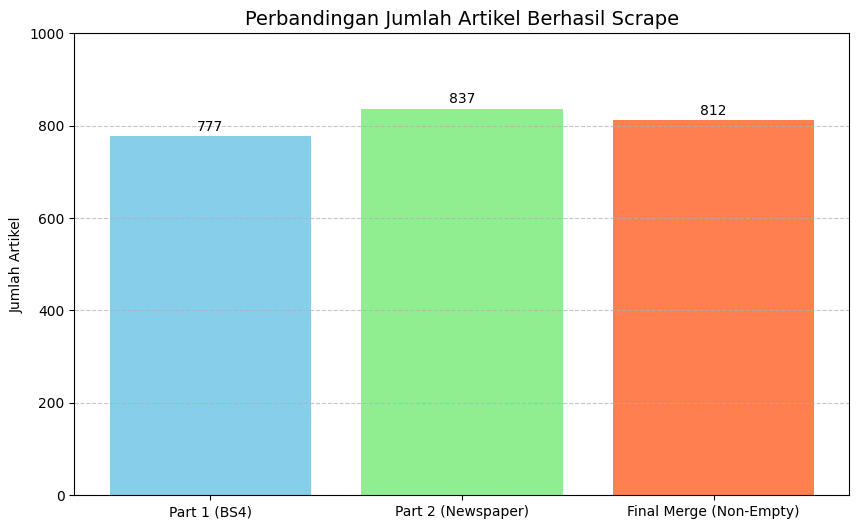

In [ ]:
import matplotlib.pyplot as plt

# Data berdasarkan log eksekusi sebelumnya
labels = ['Part 1 (BS4)', 'Part 2 (Newspaper)', 'Final Merge (Non-Empty)']
# Sukses Part 1: 777, Sukses Part 2: 837
# Total baris 1053, Kosong 241 -> Berhasil: 1053 - 241 = 812
counts = [777, 837, 812]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, counts, color=['skyblue', 'lightgreen', 'coral'])

# Menambahkan label angka di atas batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom')

plt.title('Perbandingan Jumlah Artikel Berhasil Scrape', fontsize=14)
plt.ylabel('Jumlah Artikel')
plt.ylim(0, 1000)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

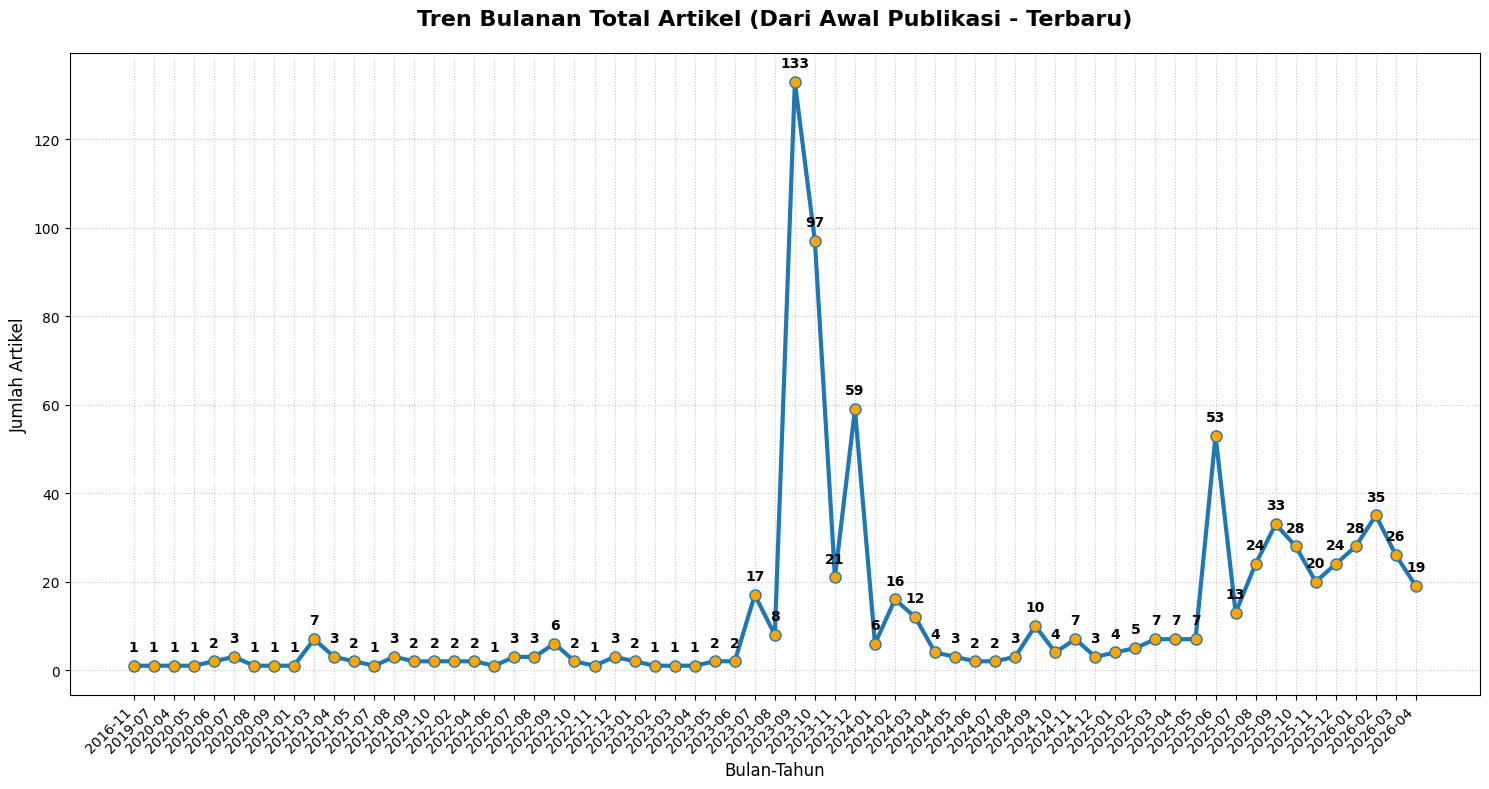

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'scraped_articles_merged.csv'
df_merged = pd.read_csv(file_path)

df_clean = df_merged.dropna(subset=['content']).copy()
df_clean['published'] = pd.to_datetime(df_clean['published'], errors='coerce')
df_clean = df_clean.dropna(subset=['published'])

df_clean['month_year'] = df_clean['published'].dt.strftime('%Y-%m')

trend_data = df_clean.groupby('month_year').size().sort_index()

plt.figure(figsize=(15, 8))
plt.plot(trend_data.index, trend_data.values, marker='o', color='#1f77b4', linewidth=3, markersize=8, markerfacecolor='orange')

plt.title('Tren Bulanan Total Artikel (Dari Awal Publikasi - Terbaru)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Bulan-Tahun', fontsize=12)
plt.ylabel('Jumlah Artikel', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

offset_label = trend_data.max() * 0.02
for i, v in enumerate(trend_data.values):
    plt.text(i, v + offset_label, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
min_date = df_clean['published'].min()
max_date = df_clean['published'].max()

print(f'Tanggal Terlama: {min_date}')
print(f'Tanggal Terbaru: {max_date}')

Tanggal Terlama: 2016-11-24 08:00:00
Tanggal Terbaru: 2026-04-14 11:19:15
